In [4]:
#Terceros
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Este proyecto
import set_paths
from config.paths import RAW_DATA
from src.pipeline import full_treatment

## SCORE
$$

score = w_1*(precio\, mediano\, m2) + w_2*(1 - edad\, anuncios\, promedio) + w_3*(1-coef.\, var)

$$

In [40]:
def get_top(data: pd.DataFrame, top:int = 10, criterion: str = "score") -> pd.DataFrame:
    top_data = data.sort_values(by=criterion, ascending=False).head(top)
    return top_data

In [44]:
#test
normalized = full_treatment(RAW_DATA / "properties_morelos.csv")
top = 10
vis_test = get_top(normalized, top = 10, criterion= "score")
vis_test[["municipio", "colonia", "score"]]

,municipio,colonia,score
150,Emiliano Zapata,Fraccionamiento Paraíso Country Club,0.864967
123,Cuernavaca,Reforma,0.781319
166,Emiliano Zapata,Tres de Mayo,0.710020
95,Cuernavaca,Lomas de Cortes,0.695253
39,Cuernavaca,Chapultepec,0.687458
1,Atlatlahucan,Fraccionamiento Lomas de Cocoyoc,0.677248
138,Cuernavaca,Vista Hermosa,0.664317
48,Cuernavaca,Delicias,0.624900
221,Temixco,Fraccionamiento Burgos Bugambilias,0.604332
110,Cuernavaca,Palmira Tingüindín,0.562925


In [ ]:
def bar_plot(data: pd.DataFrame, criterion: str, **barplot_args: dict):

    labels = [f"{data["colonia"].iloc[i]} ({data["municipio"].iloc[i]})"for i in range(top)]

    plt.title(f"Las {top} Colonias con mayor Score en Morelos")
    ax = sns.barplot(data = data, y = "colonia", x = criterion, orient = "y", **barplot_args)
    plt.xlabel("Score")
    plt.ylabel("Colonia (municipio)")
    plt.yticks([])

    ax.bar_label(ax.containers[0],
    labels = labels,
    label_type = "center", color = "white")
    plt.show()

    return None

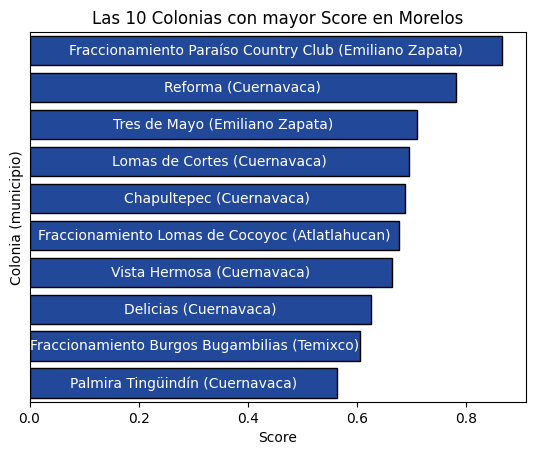

In [ ]:
labels = [f"{vis_test["colonia"].iloc[i]} ({vis_test["municipio"].iloc[i]})"for i in range(top)]
plt.title(f"Las {top} Colonias con mayor Score en Morelos")
ax = sns.barplot(data = vis_test, y = "colonia", x = "score", orient = "y", color = "#0e41adeb", edgecolor = "black")
plt.xlabel("Score")
plt.ylabel("Colonia (municipio)")
plt.yticks([])

ax.bar_label(ax.containers[0],
labels = labels,
label_type = "center", color = "white")
plt.show()

